In [1]:
import os
import sys
from pathlib import Path
import numpy as np
import torch
from torch.utils.data import DataLoader

import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

from datasets import load_dataset
from transformers import AutoTokenizer, AutoModelForSequenceClassification, DataCollatorWithPadding

# Setup paths (basato sul tuo script precedente)
ROOT = Path.cwd().resolve().parent
if str(ROOT / "src") not in sys.path:
    sys.path.append(str(ROOT / "src"))

from project_paths import get_paths
paths = get_paths(ROOT)
DATA_DIR = paths.data_processed
CKPT_DIR = paths.checkpoints

print("ROOT:", ROOT)
print("DATA_DIR:", DATA_DIR)
print("CKPT_DIR:", CKPT_DIR)

c:\Users\cola0\AppData\Local\Programs\Python\Python310\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


ROOT: C:\Users\cola0\Desktop\nlp.project-Colangelo-2526
DATA_DIR: C:\Users\cola0\Desktop\nlp.project-Colangelo-2526\data\processed
CKPT_DIR: C:\Users\cola0\Desktop\nlp.project-Colangelo-2526\checkpoints


In [2]:
teacher_path = CKPT_DIR / "bert_teacher_finetuned" / "checkpoint-18000"
phase1_ckpt_path = CKPT_DIR / "tinybert_phase1" / "checkpoint-50624"
student_path = CKPT_DIR / "tinybert_phase2" / "checkpoint-13000"

print("Teacher:", teacher_path)
print("Phase1 ckpt (per fit_dense):", phase1_ckpt_path)
print("Student phase2:", student_path)

assert teacher_path.exists(), f"Non esiste: {teacher_path}"
assert phase1_ckpt_path.exists(), f"Non esiste: {phase1_ckpt_path}"
assert student_path.exists(), f"Non esiste: {student_path}"

Teacher: C:\Users\cola0\Desktop\nlp.project-Colangelo-2526\checkpoints\bert_teacher_finetuned\checkpoint-18000
Phase1 ckpt (per fit_dense): C:\Users\cola0\Desktop\nlp.project-Colangelo-2526\checkpoints\tinybert_phase1\checkpoint-50624
Student phase2: C:\Users\cola0\Desktop\nlp.project-Colangelo-2526\checkpoints\tinybert_phase2\checkpoint-13000


In [3]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

def load_state_dict_from_checkpoint(ckpt_dir: Path):
    """
    Legge model.safetensors (preferito) o pytorch_model.bin dalla cartella checkpoint-*.
    """
    st_path = ckpt_dir / "model.safetensors"
    bin_path = ckpt_dir / "pytorch_model.bin"

    if st_path.exists():
        from safetensors.torch import load_file
        return load_file(str(st_path))
    if bin_path.exists():
        return torch.load(str(bin_path), map_location="cpu")

    raise FileNotFoundError(f"Nessun model.safetensors / pytorch_model.bin in {ckpt_dir}")

Device: cuda


In [4]:
def try_recover_projection_from_phase1(phase1_ckpt: Path, student_idx: int = 4):
    """
    Cerca fit_dense.{student_idx}.weight (+ bias opzionale) nello state_dict del checkpoint phase1.
    Nel tuo trainer Phase1DistillationTrainer la proiezione è model.fit_dense[student_idx]. :contentReference[oaicite:1]{index=1}
    """
    sd = load_state_dict_from_checkpoint(phase1_ckpt)

    w_key = f"fit_dense.{student_idx}.weight"
    b_key = f"fit_dense.{student_idx}.bias"

    if w_key not in sd:
        return None

    # In torch: Linear(out,in) salva weight [out, in] -> qui [768, 312]
    W_out_in = sd[w_key].cpu().numpy()  # [768,312]
    b = sd[b_key].cpu().numpy() if b_key in sd else None

    # Per proiettare con prodotto a destra: S @ W + b, serve W [312,768]
    W = W_out_in.T  # [312,768]
    if b is None:
        b = np.zeros((W.shape[1],), dtype=np.float32)
    return W.astype(np.float32), b.astype(np.float32)

def fit_linear_projection_ridge(S, T, alpha=1e-3, fit_bias=True):
    """
    Fit post-hoc (ridge) di W: S (312D) -> T (768D).
    S: [N,312], T: [N,768]
    """
    S = np.asarray(S, dtype=np.float64)
    T = np.asarray(T, dtype=np.float64)

    if fit_bias:
        S_aug = np.concatenate([S, np.ones((S.shape[0], 1), dtype=np.float64)], axis=1)  # [N,313]
    else:
        S_aug = S

    d_in = S_aug.shape[1]
    I = np.eye(d_in, dtype=np.float64)

    A = S_aug.T @ S_aug + alpha * I
    B = S_aug.T @ T
    W_aug = np.linalg.solve(A, B)  # [d_in, 768]

    if fit_bias:
        W = W_aug[:-1, :]          # [312,768]
        b = W_aug[-1, :]           # [768]
    else:
        W = W_aug
        b = np.zeros((T.shape[1],), dtype=np.float64)

    return W.astype(np.float32), b.astype(np.float32)

In [5]:
test_path = DATA_DIR / "test.parquet"
assert test_path.exists(), f"Non esiste: {test_path}"

test_ds = load_dataset("parquet", data_files=str(test_path))["train"]

# uniforma nome label
if "labels" not in test_ds.column_names and "label" in test_ds.column_names:
    test_ds = test_ds.rename_column("label", "labels")

# campionamento (t-SNE è pesante)
N = 12000
rng = np.random.default_rng(42)
idx = rng.choice(len(test_ds), size=min(N, len(test_ds)), replace=False)
sample_ds = test_ds.select(idx)

# tieni solo colonne tokenizzate + labels
cols_keep = ["input_ids", "attention_mask", "token_type_ids", "labels"]
cols_keep = [c for c in cols_keep if c in sample_ds.column_names]
cols_remove = [c for c in sample_ds.column_names if c not in cols_keep]
sample_ds = sample_ds.remove_columns(cols_remove).with_format("torch")

# tokenizer serve solo per padding coerente
tokenizer = AutoTokenizer.from_pretrained(str(teacher_path))
collator = DataCollatorWithPadding(tokenizer, return_tensors="pt")

dl = DataLoader(sample_ds, batch_size=128, shuffle=False, collate_fn=collator)

print("Sample size:", len(sample_ds))
print("Columns:", sample_ds.column_names)

Sample size: 12000
Columns: ['labels', 'input_ids', 'attention_mask', 'token_type_ids']


In [6]:
teacher = AutoModelForSequenceClassification.from_pretrained(str(teacher_path)).to(device)
student = AutoModelForSequenceClassification.from_pretrained(str(student_path)).to(device)

teacher.eval()
student.eval()

print("Loaded teacher + student.")

Loaded teacher + student.


In [7]:
@torch.no_grad()
def extract_cls_last(model, dataloader):
    all_cls, all_y = [], []
    for batch in dataloader:
        batch = {k: v.to(device) for k, v in batch.items()}

        y = batch["labels"].detach().cpu().numpy()

        inputs = {k: batch[k] for k in ["input_ids", "attention_mask"] if k in batch}
        if "token_type_ids" in batch:
            inputs["token_type_ids"] = batch["token_type_ids"]

        out = model(**inputs, output_hidden_states=True, return_dict=True)
        cls = out.hidden_states[-1][:, 0, :].detach().cpu().numpy()  # CLS last layer
        all_cls.append(cls)
        all_y.append(y)

    return np.vstack(all_cls), np.concatenate(all_y)

T, y = extract_cls_last(teacher, dl)   # [N, 768]
S, _ = extract_cls_last(student, dl)   # [N, 312] (TinyBERT4)

print("Teacher CLS:", T.shape)
print("Student CLS:", S.shape)
print("Labels:", np.bincount(y.astype(int)))

Teacher CLS: (12000, 768)
Student CLS: (12000, 312)
Labels: [8878 3122]


In [8]:
recovered = try_recover_projection_from_phase1(phase1_ckpt_path, student_idx=4)

if recovered is not None:
    W, b = recovered
    print("✅ fit_dense[4] recuperata dal checkpoint phase1:", phase1_ckpt_path)
else:
    print("⚠️ fit_dense[4] NON trovata nel checkpoint phase1. Faccio fit post-hoc ridge...")
    W, b = fit_linear_projection_ridge(S, T, alpha=1e-3, fit_bias=True)

S_proj = S @ W + b  # [N,768]
print("S_proj:", S_proj.shape)

✅ fit_dense[4] recuperata dal checkpoint phase1: C:\Users\cola0\Desktop\nlp.project-Colangelo-2526\checkpoints\tinybert_phase1\checkpoint-50624
S_proj: (12000, 768)


In [9]:
def cosine_sim(a, b, eps=1e-8):
    a = a / (np.linalg.norm(a, axis=1, keepdims=True) + eps)
    b = b / (np.linalg.norm(b, axis=1, keepdims=True) + eps)
    return np.sum(a * b, axis=1)

cos = cosine_sim(T, S_proj)
print(f"Cosine similarity (overall): mean={cos.mean():.4f}  std={cos.std():.4f}  median={np.median(cos):.4f}")

for label in [0, 1]:
    m = (y == label)
    if m.sum() > 0:
        print(f"  label={label}  n={m.sum()}  mean={cos[m].mean():.4f}  std={cos[m].std():.4f}  median={np.median(cos[m]):.4f}")

Cosine similarity (overall): mean=0.7817  std=0.0753  median=0.7851
  label=0  n=8878  mean=0.7735  std=0.0702  median=0.7787
  label=1  n=3122  mean=0.8050  std=0.0840  median=0.8165


## Plot 1: PCA (to reduce to 150 dimensions) + t-SNE (to further reduce to 2D)

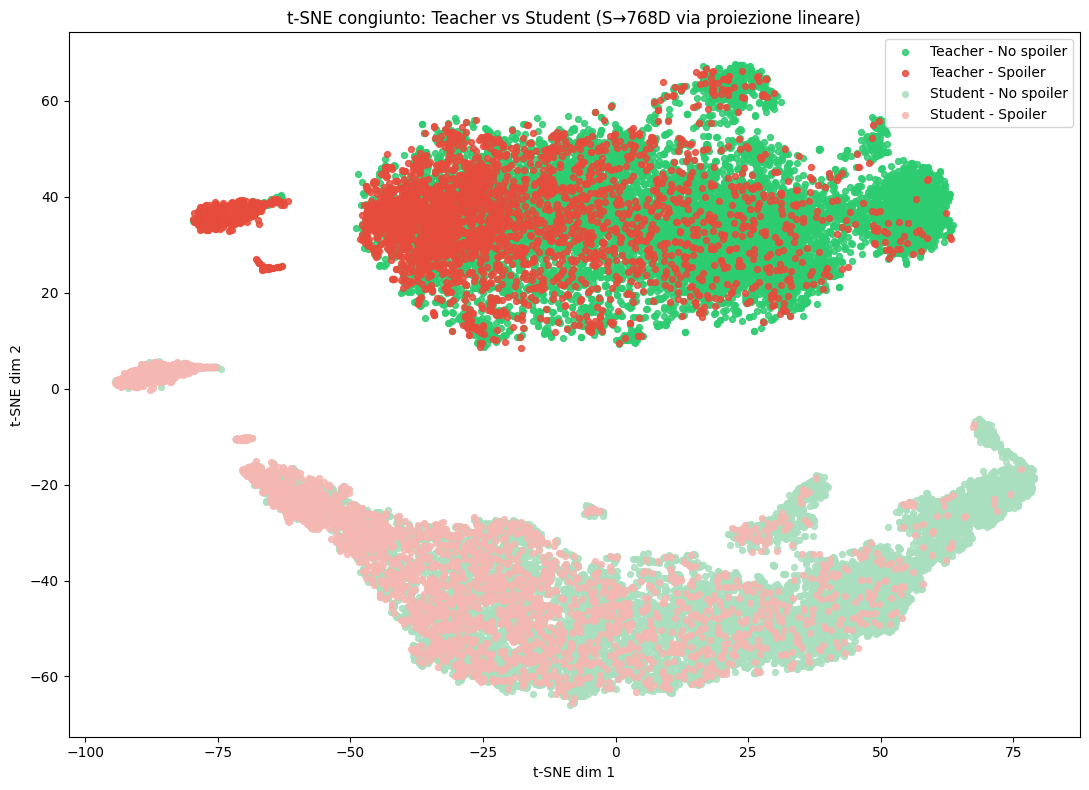

In [ ]:
# concatena: prima tutti i teacher, poi tutti gli student proiettati
X = np.vstack([T, S_proj])  # [2N, 768]
# PCA a 50D (come fai tu)
pca = PCA(n_components=150, random_state=42)
X50 = pca.fit_transform(X)

# t-SNE congiunto (un solo fit)
tsne = TSNE(
    n_components=2,
    perplexity=80,
    random_state=42,
    init="pca",
    learning_rate="auto",
    max_iter=2000,
    metric="cosine"
)
Z = tsne.fit_transform(X50)  # [2N,2]

Z_T = Z[:len(T)]
Z_S = Z[len(T):]

# colori richiesti:
# spoiler teacher = rosso, no spoiler teacher = verde
# spoiler student = rosso chiaro, no spoiler student = verde chiaro
C_TEACH = {0: "#2ecc71", 1: "#e74c3c"}   # verde / rosso
C_STUD  = {0: "#a9dfbf", 1: "#f5b7b1"}   # verde chiaro / rosso chiaro

plt.figure(figsize=(11, 8))

# Teacher
for lab in [0, 1]:
    m = (y == lab)
    plt.scatter(
        Z_T[m, 0], Z_T[m, 1],
        s=18, alpha=0.85, c=C_TEACH[lab],
        label=f"Teacher - {'No spoiler' if lab==0 else 'Spoiler'}"
    )

# Student (proiettato)
for lab in [0, 1]:
    m = (y == lab)
    plt.scatter(
        Z_S[m, 0], Z_S[m, 1],
        s=18, alpha=0.85, c=C_STUD[lab],
        label=f"Student - {'No spoiler' if lab==0 else 'Spoiler'}"
    )

plt.title("t-SNE congiunto: Teacher vs Student (S→768D via proiezione lineare)")
plt.xlabel("t-SNE dim 1")
plt.ylabel("t-SNE dim 2")
plt.legend()
plt.tight_layout()
plt.show()

## Plot 2: UMAP

## Plot 3: PCA only

## Plot 4: UMAP/PCA on a tricky word